In [0]:
reviews_df = spark.read.parquet(
"/Volumes/project/project_amazon/amazon_reviews/Video_Games.parquet"
)

reviews_df.printSchema()
reviews_df.show(5)

root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- small_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- attachment_type: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

+------+--------------------+--------------------+------+----------+-----------+--------------------+-------------+------------+-----------------+
|rating|               title|                text|images|      asin|parent_asin|             user_id|    timestamp|helpful_vote|verified_purchase|
+------+------------------

In [0]:
import pyarrow.parquet as pq
import pandas as pd

# Use PyArrow to read the Parquet file and handle duplicate columns
parquet_path = "/Volumes/project/project_amazon/amazon_reviews/meta_Video_Games.parquet"
table = pq.read_table(parquet_path)

# Deduplicate column names
cols = table.column_names
seen = {}
deduped_cols = []

for c in cols:
    if c in seen:
        seen[c] += 1
        deduped_cols.append(f"{c}_{seen[c]}")
    else:
        seen[c] = 0
        deduped_cols.append(c)

# Create pandas DataFrame with deduplicated columns
pandas_df = table.to_pandas()
pandas_df.columns = deduped_cols

# Convert to Spark DataFrame
meta_df = spark.createDataFrame(pandas_df)

print(meta_df.columns)

['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [0]:
reviews_df.show(5, truncate=False)

+------+------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+----------+-----------+----------------------------+-------------+------------+-----------------+
|rating|title                                                                   |text                                                                                                                                                                                                                              |images|asin      |parent_asin|user_id                     |timestamp    |helpful_vote|verified_purchase|
+------+------------------------------------------------------------------------+---------------------------------------------------------------------------------------------

In [0]:
meta_df.printSchema()

root
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- hi_res: string (nullable = true)
 |    |    |-- large: string (nullable = true)
 |    |    |-- thumb: string (nullable = true)
 |    |    |-- variant: string (nullable = true)
 |-- videos: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- title: string (nullable = true)
 |    |    |-- url: string (nullable = true)
 |    |    |-- user_id: string (nullable = true)
 |-- store: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (con

In [0]:
meta_df.show(10, truncate=False)

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:443)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:503)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:794)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperation$1(UsageLogging.scala:531)
	at com.databricks.logging.UsageLogging.executeThunkAndCaptureResultTags$1(UsageLogging.scala:683)
	at com.databricks.logging.UsageLogging.$anonfun$recordOperationWithResultTags$5(UsageLogging.scala:710)
	at com.databricks.logging.AttributionContextTracing.$anonfun$withAttributionContext$1(AttributionContextTracing.scala:146)
	at com.databricks.logging.AttributionContext$.$anonfun$withValue$1(AttributionContext.scala:349)
	at scala.util.DynamicVariable.withValue(DynamicVariable.scala:59)
	at com.databricks.logging.AttributionContext$.withValue(Att

In [0]:
print("Reviews Rows:", reviews_df.count())
print("Meta Rows:", meta_df.count())

Reviews Rows: 4624615
Meta Rows: 137269


In [0]:
print("Reviews Columns:", len(reviews_df.columns))
print("Meta Columns:", len(meta_df.columns))

Reviews Columns: 10
Meta Columns: 16


In [0]:
from pyspark.sql.functions import rand

sample_df = reviews_df.orderBy(rand()).limit(5000)

In [0]:
sample_df.count()

5000

In [0]:
from pyspark.sql.functions import *

sample_df.select([
    count(when(col(c).isNull(),c)).alias(c)
    for c in sample_df.columns
]).show()

+------+-----+----+------+----+-----------+-------+---------+------------+-----------------+
|rating|title|text|images|asin|parent_asin|user_id|timestamp|helpful_vote|verified_purchase|
+------+-----+----+------+----+-----------+-------+---------+------------+-----------------+
|     0|    0|   0|     0|   0|          0|      0|        0|           0|                0|
+------+-----+----+------+----+-----------+-------+---------+------------+-----------------+



In [0]:
sample_df.printSchema()

root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- small_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- attachment_type: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [0]:
sample_df = sample_df.withColumn(
    "review_date",
    from_unixtime(col("timestamp")/1000)
)

In [0]:
sample_df = sample_df.withColumn(
    "review_date",
    to_timestamp("review_date")
)

In [0]:
sample_df.select(
    "timestamp",
    "review_date"
).show(5)

+-------------+-------------------+
|    timestamp|        review_date|
+-------------+-------------------+
|1484508996000|2017-01-15 19:36:36|
|1423769979000|2015-02-12 19:39:39|
|1597591662179|2020-08-16 15:27:42|
|1613773309437|2021-02-19 22:21:49|
|1568142512467|2019-09-10 19:08:32|
+-------------+-------------------+
only showing top 5 rows


In [0]:
full_df = sample_df.join(
    meta_df,
    on="parent_asin",
    how="left"
)

In [0]:
full_df.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- small_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- attachment_type: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- review_date: timestamp (nullable = true)
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description:

In [0]:
full_df.groupBy("rating")\
       .count()\
       .orderBy("rating")\
       .show()

+------+-----+
|rating|count|
+------+-----+
|   1.0|  686|
|   2.0|  280|
|   3.0|  352|
|   4.0|  666|
|   5.0| 3016|
+------+-----+



In [0]:
full_df.groupBy("verified_purchase")\
       .count()\
       .show()

+-----------------+-----+
|verified_purchase|count|
+-----------------+-----+
|             true| 4290|
|            false|  710|
+-----------------+-----+



In [0]:
from pyspark.sql.functions import year

full_df.groupBy(
    year("review_date").alias("year")
).count().orderBy("year").show()

+----+-----+
|year|count|
+----+-----+
|2000|    7|
|2001|   12|
|2002|   14|
|2003|   14|
|2004|    9|
|2005|   18|
|2006|   18|
|2007|   28|
|2008|   48|
|2009|   59|
|2010|   69|
|2011|  128|
|2012|  110|
|2013|  272|
|2014|  333|
|2015|  429|
|2016|  449|
|2017|  359|
|2018|  423|
|2019|  470|
+----+-----+
only showing top 20 rows


In [0]:
full_df = full_df.withColumn(
    "sentiment",
    when(col("rating")>=4,1).otherwise(0)
)

In [0]:
full_df.groupBy("sentiment").count().show()

+---------+-----+
|sentiment|count|
+---------+-----+
|        1| 3682|
|        0| 1318|
+---------+-----+



In [0]:
text_df = full_df.select(
    "text",
    "sentiment"
).dropna()

In [0]:
# Convert to pandas for sklearn processing
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import re

text_pandas = text_df.toPandas()

In [0]:
import re

text_pandas['text'] = (
    text_pandas['text']
    .astype(str)
    .apply(
        lambda x:
        re.sub(r'<.*?>',' ',x)
    )
)

In [0]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    stop_words='english',
    min_df=5
)

analyzer = cv.build_analyzer()

text_pandas['clean_text'] = (
    text_pandas['text']
    .apply(
        lambda x:
        " ".join(analyzer(x))
    )
)

In [0]:
clean_df = text_pandas

In [0]:
print(clean_df)

                                                   text  ...                                         clean_text
0                                            great game  ...                                         great game
1                                             Happy kid  ...                                          happy kid
2              I bought this for my son and he loves it  ...                                   bought son loves
3     This cooler is terribly designed.  This is des...  ...  cooler terribly designed designed blow ps5 fin...
4     Ok, I tired buying things that don't work. Tem...  ...  ok tired buying things don work tempered glass...
...                                                 ...  ...                                                ...
4995  I guess I can add my name to the long, sad lis...  ...  guess add long sad list people spent 150 contr...
4996                                  I love this game!  ...                                          lo

In [0]:
X_count = cv.fit_transform(
    clean_df['clean_text']
)

In [0]:
idx = 100

print("Original:")
print(clean_df['text'].iloc[idx])

print("\nAfter Stopword Removal:")
print(clean_df['clean_text'].iloc[idx])

Original:
3 months later they stopped working

After Stopword Removal:
months later stopped working


In [0]:
print("Original Text:")
print(clean_df['text'].iloc[2])


Original Text:
I bought this for my son and he loves it


In [0]:
print("\nAfter Stopword Removal:")
print(clean_df['clean_text'].iloc[2])


After Stopword Removal:
bought son loves


In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(
    clean_df['clean_text']
)

In [0]:
y = clean_df['sentiment']

In [0]:
from sklearn.model_selection import train_test_split

y = clean_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4000, 12888)
(1000, 12888)


In [0]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [0]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test,y_pred_nb))
print("Precision:", precision_score(y_test,y_pred_nb))
print("Recall   :", recall_score(y_test,y_pred_nb))
print("F1 Score :", f1_score(y_test,y_pred_nb))

Accuracy : 0.752
Precision: 0.7479674796747967
Recall   : 1.0
F1 Score : 0.8558139534883721


In [0]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

In [0]:
print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision:", precision_score(y_test,y_pred_lr))
print("Recall   :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))

Accuracy : 0.823
Precision: 0.813692480359147
Recall   : 0.9850543478260869
F1 Score : 0.8912108174554395


In [0]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [0]:
print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall   :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))

Accuracy : 0.827
Precision: 0.8187995469988675
Recall   : 0.9823369565217391
F1 Score : 0.8931439159975293


In [0]:
comparison = pd.DataFrame({
    'Model':['Naive Bayes',
             'Logistic Regression',
             'Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],
    'F1 Score':[
        f1_score(y_test,y_pred_nb),
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Naive Bayes,0.752,0.855814
1,Logistic Regression,0.823,0.891211
2,Random Forest,0.827,0.893144


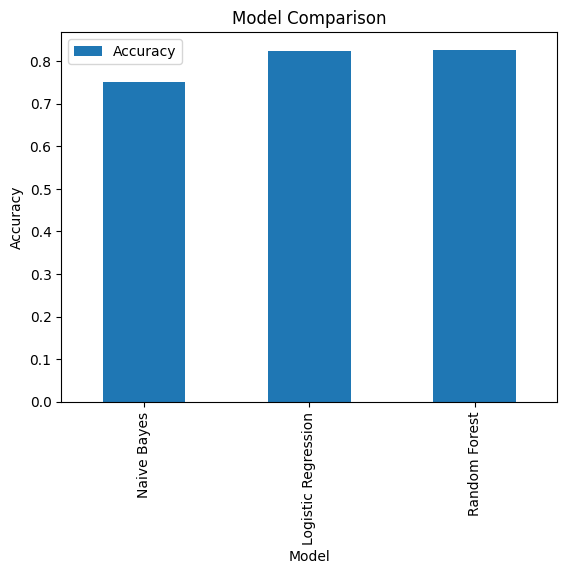

In [0]:
import matplotlib.pyplot as plt

comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [0]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[ 98 166]
 [ 11 725]]


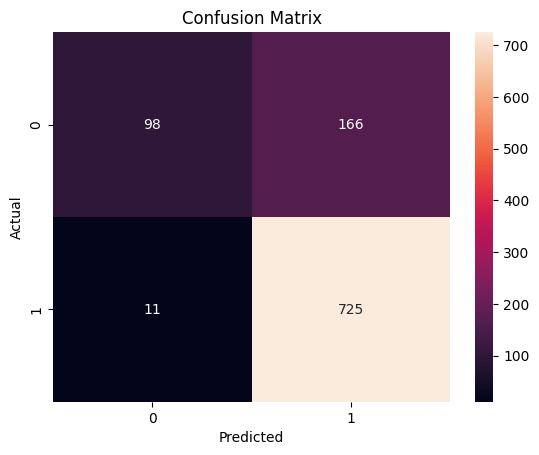

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [0]:
coef = lr.coef_[0]

feature_names = tfidf.get_feature_names_out()

importance = pd.DataFrame({
    'word':feature_names,
    'coefficient':coef
})

top_positive = importance.sort_values(
    'coefficient',
    ascending=False
).head(20)

print(top_positive)

            word  coefficient
5108       great     4.668976
6763        love     3.918522
8225     perfect     2.690850
1080     awesome     2.637220
6769       loves     2.574588
1305        best     2.562819
12694      works     2.499158
5023        good     2.466027
703      amazing     2.439189
4067   excellent     2.252964
3721        easy     2.226986
8230   perfectly     2.167671
7592        nice     2.125626
5286       happy     1.949156
10591        son     1.891937
4752         fun     1.745136
6764       loved     1.733136
4477        fits     1.508143
4051     exactly     1.402898
6157         job     1.391639


In [0]:
top_negative = importance.sort_values(
    'coefficient'
).head(20)

print(top_negative)

               word  coefficient
3239            did    -2.599078
10977       stopped    -2.559738
12686          work    -2.467271
7334         months    -2.377169
1625          broke    -2.367594
11474      terrible    -2.358919
12475         waste    -2.265563
3243           didn    -2.168324
9585         return    -1.953510
9586       returned    -1.932978
7332          month    -1.872496
8530           poor    -1.868478
11860         tried    -1.779260
12712        wouldn    -1.765868
3326   disappointed    -1.731858
12197       useless    -1.681492
12287       version    -1.647279
1626         broken    -1.637628
6506           left    -1.634984
12705         worst    -1.605715


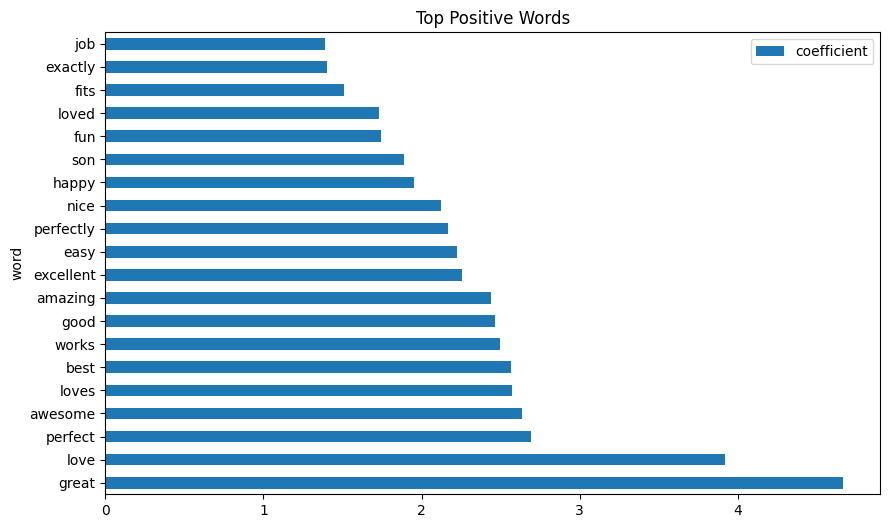

In [0]:
top_positive.plot(
    x='word',
    y='coefficient',
    kind='barh',
    figsize=(10,6)
)

plt.title("Top Positive Words")
plt.show()

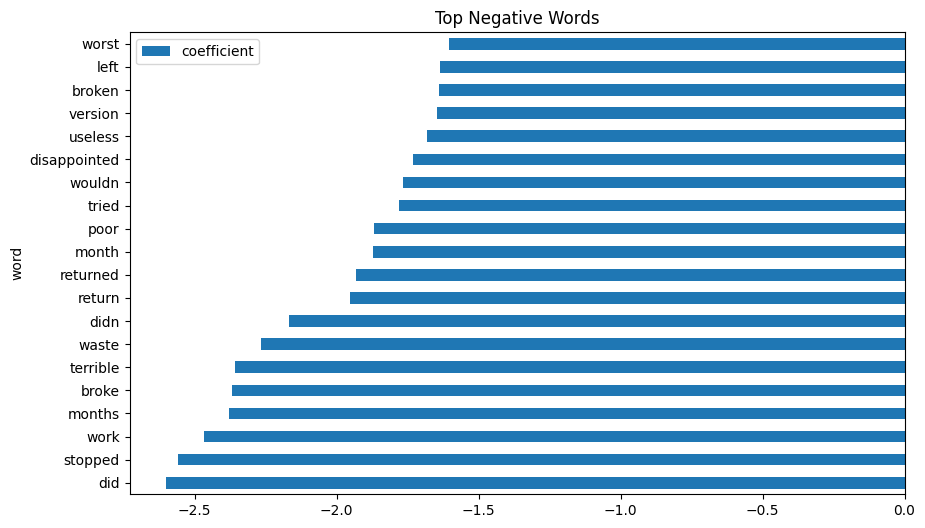

In [0]:
top_negative.plot(
    x='word',
    y='coefficient',
    kind='barh',
    figsize=(10,6)
)

plt.title("Top Negative Words")
plt.show()

In [0]:
clean_df['review_length'] = (
    clean_df['clean_text']
    .apply(len)
)

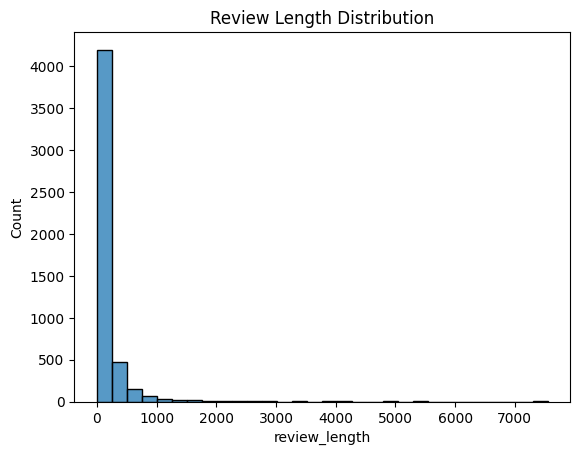

In [0]:
import seaborn as sns

sns.histplot(
    clean_df['review_length'],
    bins=30
)

plt.title("Review Length Distribution")
plt.show()

In [0]:
clean_df['sentiment'].value_counts()

sentiment
1    3682
0    1318
Name: count, dtype: int64

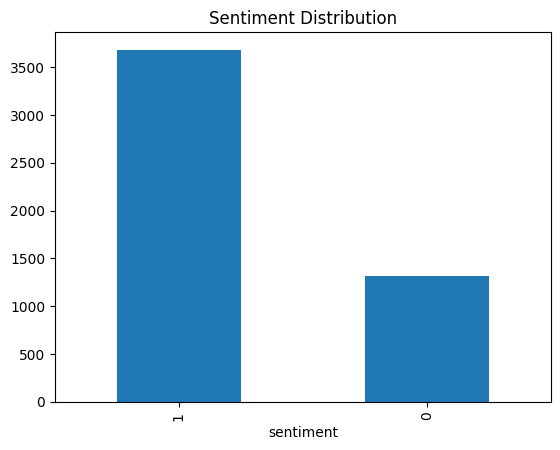

In [0]:
clean_df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")
plt.show()

In [0]:
# Transformer-Based Sentiment Analysis (DistilBERT)

In [0]:
%pip install transformers torch

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from transformers import pipeline

In [0]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [0]:
sample_review = clean_df['text'].iloc[0]

result = sentiment_model(
    sample_review[:512]
)

print(result)

[{'label': 'POSITIVE', 'score': 0.9998661279678345}]


In [0]:
sample_df = clean_df.sample(
    500,
    random_state=42
)

reviews = sample_df['text'].tolist()

predictions = sentiment_model(
    [review[:512] for review in reviews]
)

In [0]:
bert_pred = []

for pred in predictions:

    if pred['label'] == 'POSITIVE':
        bert_pred.append(1)

    else:
        bert_pred.append(0)

In [0]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

y_true = sample_df['sentiment']

bert_acc = accuracy_score(y_true, bert_pred)
bert_precision = precision_score(y_true, bert_pred)
bert_recall = recall_score(y_true, bert_pred)
bert_f1 = f1_score(y_true, bert_pred)

print("Accuracy :", bert_acc)
print("Precision:", bert_precision)
print("Recall   :", bert_recall)
print("F1 Score :", bert_f1)

Accuracy : 0.854
Precision: 0.9393939393939394
Recall   : 0.8539944903581267
F1 Score : 0.8946608946608947


In [0]:
nb_acc = accuracy_score(y_test, y_pred_nb)
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

comparison

,Model,Accuracy,F1 Score
0,Naive Bayes,0.752,0.855814
1,Logistic Regression,0.823,0.891211
2,Random Forest,0.827,0.893144


In [0]:
comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'Random Forest',
        'DistilBERT'
    ],
    'Accuracy': [
        nb_acc,
        lr_acc,
        rf_acc,
        bert_acc
    ]
})

comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,DistilBERT,0.854
2,Random Forest,0.827
1,Logistic Regression,0.823
0,Naive Bayes,0.752


In [0]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

In [0]:
sample_review = clean_df['text'].iloc[0]

print(sample_review)

great game


In [0]:
tokens = tokenizer.tokenize(sample_review)

print(tokens[:100])

['great', 'game']


In [0]:
token_ids = tokenizer.encode(
    sample_review,
    add_special_tokens=True
)

print(token_ids[:50])

[101, 2307, 2208, 102]


In [0]:
ids = tokenizer.encode(
    sample_review,
    add_special_tokens=True
)

tokens = tokenizer.convert_ids_to_tokens(ids)

for token in tokens[:50]:
    print(token)

[CLS]
great
game
[SEP]


In [0]:
text = "unbelievable gameplay"

tokens = tokenizer.tokenize(text)

print(tokens)

['unbelievable', 'gameplay']


In [0]:
sample_reviews = clean_df.sample(
    10,
    random_state=42
)[['text','sentiment']]

for idx, row in sample_reviews.iterrows():

    review = str(row['text'])[:512]

    prediction = sentiment_model(review)[0]

    actual = "POSITIVE" if row['sentiment']==1 else "NEGATIVE"

    print("="*120)

    print("Review:")
    print(review[:300])

    print("\nActual Sentiment:")
    print(actual)

    print("\nPredicted Sentiment:")
    print(prediction['label'])

    print("\nConfidence:")
    print(f"{prediction['score']:.4f}")

Review:
This thing is awesome. Dual voltage. I play my xbox when I get a chance between school and family. Great because I do not have to plug in my xbox into a transformer anymore.

Actual Sentiment:
POSITIVE

Predicted Sentiment:
POSITIVE

Confidence:
0.9998
Review:
Fun back and forth between the team members. Good value at $29.99

Actual Sentiment:
POSITIVE

Predicted Sentiment:
POSITIVE

Confidence:
0.9998
Review:
Kids love it!

Actual Sentiment:
POSITIVE

Predicted Sentiment:
POSITIVE

Confidence:
0.9999
Review:
excelente producto,

Actual Sentiment:
POSITIVE

Predicted Sentiment:
POSITIVE

Confidence:
0.9962
Review:
We tried for over 30 minutes to get the remotes linked up to the console without success. Will purchase actual Wii remotes next even though they are more money (but honestly, not much more). You get what you pay for with knockoffs.

Actual Sentiment:
NEGATIVE

Predicted Sentiment:
NEGATIVE

Confidence:
0.9976
Review:
This was a gift for my wife and she hasn't stopped 

In [0]:
hard_reviews = [
    "The product is excellent but stopped working after one week",
    "The game has amazing graphics but the controls are terrible",
    "I loved the design but the battery life is awful",
    "The sound quality is fantastic but it crashes frequently",
    "The product works well although customer support is useless"
]

results = sentiment_model(hard_reviews)

for review, result in zip(hard_reviews, results):
    print("="*100)
    print("Review:", review)
    print("Prediction:", result['label'])
    print("Confidence:", f"{result['score']:.4f}")

Review: The product is excellent but stopped working after one week
Prediction: NEGATIVE
Confidence: 0.9766
Review: The game has amazing graphics but the controls are terrible
Prediction: NEGATIVE
Confidence: 0.9913
Review: I loved the design but the battery life is awful
Prediction: NEGATIVE
Confidence: 0.9991
Review: The sound quality is fantastic but it crashes frequently
Prediction: NEGATIVE
Confidence: 0.9457
Review: The product works well although customer support is useless
Prediction: POSITIVE
Confidence: 0.8585


In [0]:
hard_reviews = [
    "The product is not good",
    "The product is not bad",
    "I do not dislike this game",
    "I am not unhappy with this purchase",
    "The product is not terrible"
]

results = sentiment_model(hard_reviews)

print("\nNEGATION REVIEWS")
print("="*100)

for review, result in zip(hard_reviews, results):
    print("\nReview:")
    print(review)

    print("\nPrediction:")
    print(result['label'])

    print("\nConfidence:")
    print(f"{result['score']:.4f}")

    print("-"*100)


NEGATION REVIEWS

Review:
The product is not good

Prediction:
NEGATIVE

Confidence:
0.9998
----------------------------------------------------------------------------------------------------

Review:
The product is not bad

Prediction:
POSITIVE

Confidence:
0.9991
----------------------------------------------------------------------------------------------------

Review:
I do not dislike this game

Prediction:
POSITIVE

Confidence:
0.9890
----------------------------------------------------------------------------------------------------

Review:
I am not unhappy with this purchase

Prediction:
POSITIVE

Confidence:
0.9966
----------------------------------------------------------------------------------------------------

Review:
The product is not terrible

Prediction:
POSITIVE

Confidence:
0.9927
----------------------------------------------------------------------------------------------------


In [0]:
hard_reviews = [
    "Fantastic, it broke on the first day",
    "Great job, now the product won't even turn on",
    "Wonderful experience, I wasted my money",
    "Amazing quality, lasted only two hours",
    "Best purchase ever... not"
]

results = sentiment_model(hard_reviews)

print("\nSARCASM REVIEWS")
print("="*100)

for review, result in zip(hard_reviews, results):
    print("\nReview:")
    print(review)

    print("\nPrediction:")
    print(result['label'])

    print("\nConfidence:")
    print(f"{result['score']:.4f}")

    print("-"*100)


SARCASM REVIEWS

Review:
Fantastic, it broke on the first day

Prediction:
POSITIVE

Confidence:
0.9999
----------------------------------------------------------------------------------------------------

Review:
Great job, now the product won't even turn on

Prediction:
NEGATIVE

Confidence:
0.9905
----------------------------------------------------------------------------------------------------

Review:
Wonderful experience, I wasted my money

Prediction:
NEGATIVE

Confidence:
0.9655
----------------------------------------------------------------------------------------------------

Review:
Amazing quality, lasted only two hours

Prediction:
POSITIVE

Confidence:
0.9985
----------------------------------------------------------------------------------------------------

Review:
Best purchase ever... not

Prediction:
POSITIVE

Confidence:
0.9991
----------------------------------------------------------------------------------------------------


In [0]:
hard_reviews = [
    """
    Initially I loved this product.
    The packaging was great and setup was easy.
    After a few days the battery started draining rapidly
    and now it doesn't work at all.
    """
]

results = sentiment_model(hard_reviews)

print("\nLONG REVIEW WITH SENTIMENT SHIFT")
print("="*100)

for review, result in zip(hard_reviews, results):
    print("\nReview:")
    print(review)

    print("\nPrediction:")
    print(result['label'])

    print("\nConfidence:")
    print(f"{result['score']:.4f}")

    print("-"*100)


LONG REVIEW WITH SENTIMENT SHIFT

Review:

    Initially I loved this product.
    The packaging was great and setup was easy.
    After a few days the battery started draining rapidly
    and now it doesn't work at all.
    

Prediction:
NEGATIVE

Confidence:
0.9980
----------------------------------------------------------------------------------------------------


In [0]:
hard_reviews = [
    "The product is excellent but stopped working after one week",
    "The product is not bad",
    "Fantastic, it broke on the first day",
    """Initially I loved this product but after a week it completely stopped working.""",
    "The camera quality is amazing but the battery drains in two hours",
    "I expected it to be terrible but it turned out surprisingly good",
    "The game is fun, however frequent crashes make it frustrating",
    "Not the best purchase, but definitely not the worst either"
]

results = sentiment_model(hard_reviews)

print("\nADVANCED SENTIMENT ANALYSIS TEST CASES")
print("="*120)

for review, result in zip(hard_reviews, results):

    print("\nReview:")
    print(review)

    print("\nPredicted Sentiment:")
    print(result['label'])

    print("\nConfidence Score:")
    print(f"{result['score']:.4f}")

    print("="*120)


ADVANCED SENTIMENT ANALYSIS TEST CASES

Review:
The product is excellent but stopped working after one week

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.9766

Review:
The product is not bad

Predicted Sentiment:
POSITIVE

Confidence Score:
0.9991

Review:
Fantastic, it broke on the first day

Predicted Sentiment:
POSITIVE

Confidence Score:
0.9999

Review:
Initially I loved this product but after a week it completely stopped working.

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.9995

Review:
The camera quality is amazing but the battery drains in two hours

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.9960

Review:
I expected it to be terrible but it turned out surprisingly good

Predicted Sentiment:
POSITIVE

Confidence Score:
0.9997

Review:
The game is fun, however frequent crashes make it frustrating

Predicted Sentiment:
NEGATIVE

Confidence Score:
0.5648

Review:
Not the best purchase, but definitely not the worst either

Predicted Sentiment:
NEGATIVE

Confid

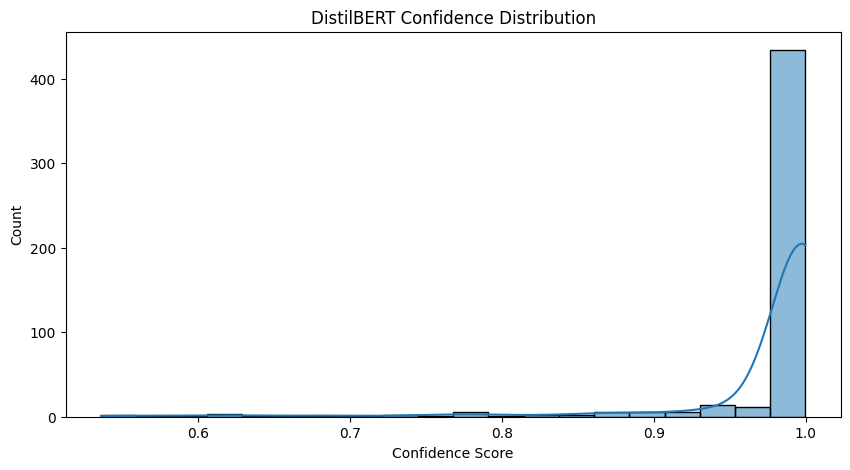

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

scores = [x['score'] for x in predictions]

plt.figure(figsize=(10,5))
sns.histplot(scores, bins=20, kde=True)

plt.title("DistilBERT Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Count")

plt.show()

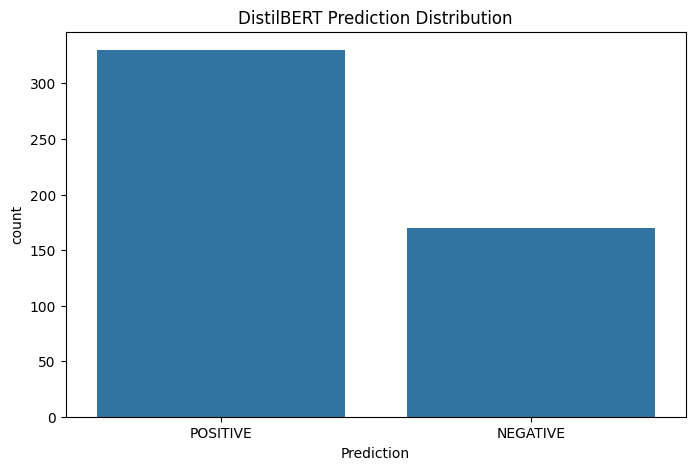

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pred_labels = [x['label'] for x in predictions]

pred_df = pd.DataFrame({
    'Prediction': pred_labels
})

plt.figure(figsize=(8,5))

sns.countplot(
    data=pred_df,
    x='Prediction'
)

plt.title("DistilBERT Prediction Distribution")

plt.show()

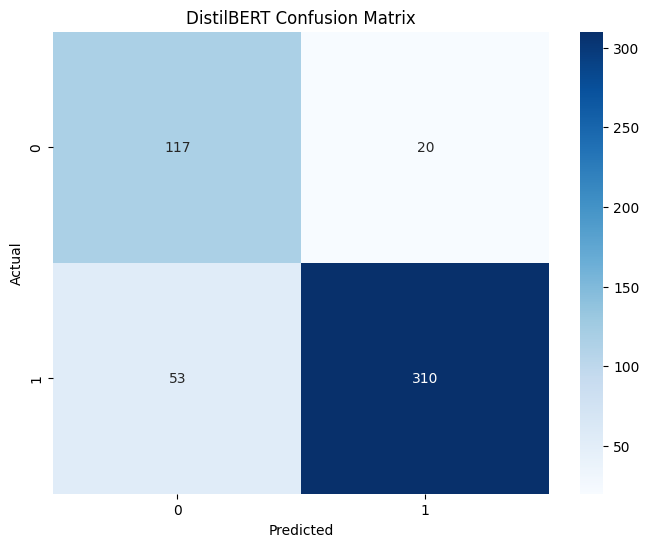

In [0]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, bert_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("DistilBERT Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

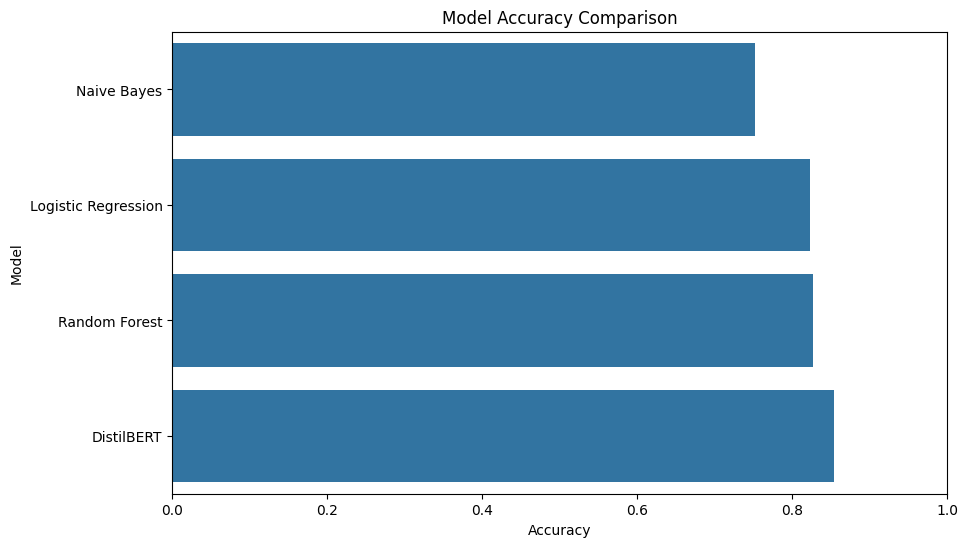

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x='Accuracy',
    y='Model'
)

plt.title("Model Accuracy Comparison")

plt.xlim(0,1)

plt.show()

In [0]:
review = """
The product is excellent but stopped working after one week
"""

result = sentiment_model(review)

print("Review:")
print(review)

print("\nPrediction:")
print(result[0]['label'])

print("\nConfidence:")
print(f"{result[0]['score']:.0f}")

Review:

The product is excellent but stopped working after one week


Prediction:
NEGATIVE

Confidence:
1
